## This notebook demonstrates how to use the lotss_object and lotss_annotations modules. It uses the `strw_lofar_data_utils` package to create cutouts from DR2 Mosaics on the STRW cluster. It is meant to demonstrate the core capabilities of said modules.

# Import necessary libraries and modules:

In [1]:
import sys
import pandas as pd
import os

from strw_lofar_data_utils.pipelines import generate_cutouts
from strw_lofar_data_utils.core.vizualization import Vizualizer

# Load a catalogue from which we will extract the RA and Dec for cutout generation:

In [2]:
GIANTS_CATALOG = "/home/penchev/strw_lofar_data_utils" + "/data/discovered_giants_catalogue.csv"
GIANTS_CATALOG

'/home/penchev/strw_lofar_data_utils/data/discovered_giants_catalogue.csv'

In [3]:
giants_df = pd.read_csv(GIANTS_CATALOG)
giants_df.head()

,recno,Name,RAJ2000,DEJ2000,LengthMpc,e_LengthMpc,LengthAng,z,e_z,Ref,FistDisc
0,10511,NaN,40.275764,8.737979,0.871,0.008,32.70,0.02121,0.00017,Oei et al. 2023,Oei et al. 2023
1,10358,NaN,38.802856,10.196330,1.014,0.607,15.60,0.05384,0.00000,Oei et al. 2023,Oei et al. 2023
2,10283,NaN,48.697044,15.149883,1.067,0.505,12.70,0.07104,0.00000,Oei et al. 2023,Oei et al. 2023
3,10938,NaN,42.945000,15.836940,0.918,0.000,2.46,0.48900,0.00000,Mahato et al. 2021,Mahato et al. 2021
4,10055,NaN,43.804028,17.514114,1.295,0.441,11.60,0.09725,0.00000,Oei et al. 2023,Oei et al. 2023


# Extract RA and Dec from the catalogue to define cutout regions:

In [4]:
# Get RA and DEC for the first 100 giants
ra_dec_list = list(
    zip(giants_df["RAJ2000"].values, giants_df["DEJ2000"].values)
)
ra_dec_list = ra_dec_list[:100]

# Generate cutouts using the defined RA and Dec coordinates:

In [5]:
cutouts = generate_cutouts(
    ra_dec_list=ra_dec_list,
    size_pixels = 300,
    save=False
)

In [6]:
print(f"Generated {len(cutouts)} cutouts.")

Generated 88 cutouts.


# Chose an example cutout to work with:

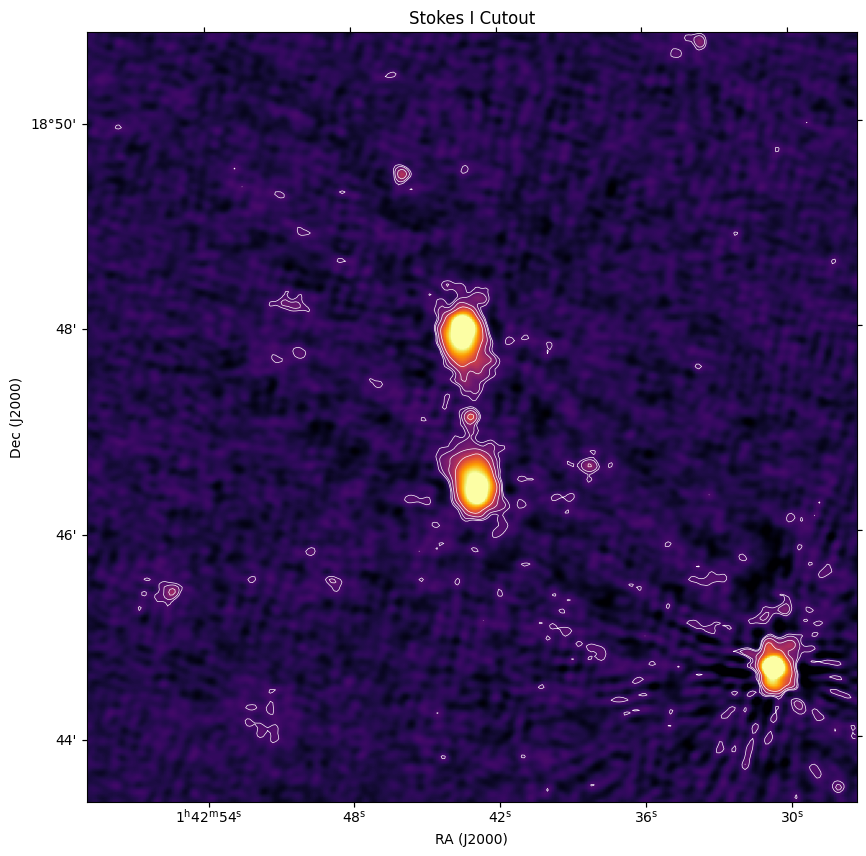

In [7]:
example_cutout = cutouts[41]

Vizualizer().vizualize_a_cutout(
    cutout=example_cutout,
    contour_levels=[3, 5, 10, 20]
)

# Example of how to do a Segment representing an object in the cutout using the Segment class:

1. First we extract the data from the cutout object.
2. Then we set the points for segmentation.
3. Finally, we visualize the segmentation.

Simple plotting functions

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import ImageNormalize, PercentileInterval, AsinhStretch

RMS = 0.1

def simple_segmentation_visualize(data, seg_object, seg_map: bool = False):
    if seg_map:
        segmentation_map, segmentation_mapping = seg_object.get_full_segmentation(data)
    else :
        segmentation_map = seg_object.get_segmentation(data)
        segmentation_mapping = None

    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
    norm = ImageNormalize(data, interval=PercentileInterval(99.5), stretch=AsinhStretch())
    im1 = ax[0].imshow(data, cmap='inferno', origin='lower', norm=norm)
    ax[0].set_title('Original Data')

    cmap = plt.cm.tab20
    im2 = ax[1].imshow(segmentation_map, origin='lower', cmap=cmap)
    ax[1].set_title('Segmentation Map')

    if segmentation_mapping is not None:
        # the dictionary contains segment_id: pixel_value_in_map
        # Normalize based on the range of values in the segmentation map
        norm_seg = plt.Normalize(vmin=segmentation_map.min(), vmax=segmentation_map.max())
        
        legend_labels = [f"Segment {seg_id}" for seg_id in segmentation_mapping.keys()]
        handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                              markerfacecolor=cmap(norm_seg(segmentation_mapping[seg_id])), markersize=10)
                   for seg_id, label in zip(segmentation_mapping.keys(), legend_labels)]
        plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
    plt.close()

def simple_bbox_visualize(data: np.ndarray, bbox_object):
    """
    Visualize the cutout with bounding boxes using matplotlib.

    :param data: 2D numpy array of the cutout data
    :param bbox_object: An object containing bounding box information
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    norm = ImageNormalize(data, interval=PercentileInterval(99.5), stretch=AsinhStretch())
    
    im = ax.imshow(data, cmap='inferno', origin='lower', norm=norm)
    
    # Assuming bbox_object has a method get_bboxes() that returns a list of bounding boxes
    bboxes = bbox_object.get_bounding_boxes(data)
    
    for bbox_name, positions in bboxes.items():
        xmin = positions['left']
        xmax = positions['right']
        ymin = positions['bottom']
        ymax = positions['top']
        rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Add label
        ax.text(xmin, ymin - 5, bbox_name, color='red', fontsize=12, weight='bold')
    
    ax.set_title('Cutout with Bounding Boxes')
    ax.set_xlabel('Pixel X')
    ax.set_ylabel('Pixel Y')
    plt.show()
    plt.close()

def show_cutout(data: np.ndarray, title: str, contour_levels: list = None, cmap='inferno', colorbar=False, save_path=None, save=False) -> None:
    """
    Show the cutout using matplotlib.

    :param title: Title for the plot
    :param contour_levels: List of contour levels in multiples of RMS noise (e.g., [3, 5, 10])
    :param cmap: Colormap for the image
    :param colorbar: Whether to show a colorbar
    :param save_path: Path to save the plot image (if save is True)
    :param save: Whether to save the plot instead of showing it
    """
    contour_levels = _make_contour_levels(contour_levels) if contour_levels is not None else None

    norm = ImageNormalize(data, interval=PercentileInterval(99.5), stretch=AsinhStretch())
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    im = ax.imshow(data, cmap=cmap, origin='lower', norm=norm)
    if colorbar:
        plt.colorbar(im, ax=ax, label='Intensity')
    if contour_levels is not None:
        ax.contour(data, levels=contour_levels, colors='white', linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('Pixel X')
    ax.set_ylabel('Pixel Y')
    if save:
        if save_path is None:
            save_path = f"{title.replace(' ', '_')}_cutout.png"
        plt.savefig(save_path)
    else:
        plt.show()
    plt.close()

def _make_contour_levels(levels: list) -> np.ndarray:
    """
    Generates contour levels based on RMS noise.
    
    :param levels: List of contour levels in multiples of RMS noise
    :return: List of contour levels in Jy/beam
    """
    return np.array(levels) * RMS * 1e-3

In [13]:
from astro_datatools.lotss_annotations import Segment

data = example_cutout.get_data()
header = example_cutout.get_header()

print(data.shape)

pixels = [(150, 110), (150, 175)]

segmenter = Segment(pixels)

segment = segmenter.get_segmentation(data)

print(segment.shape)

(300, 300)
(300, 300)


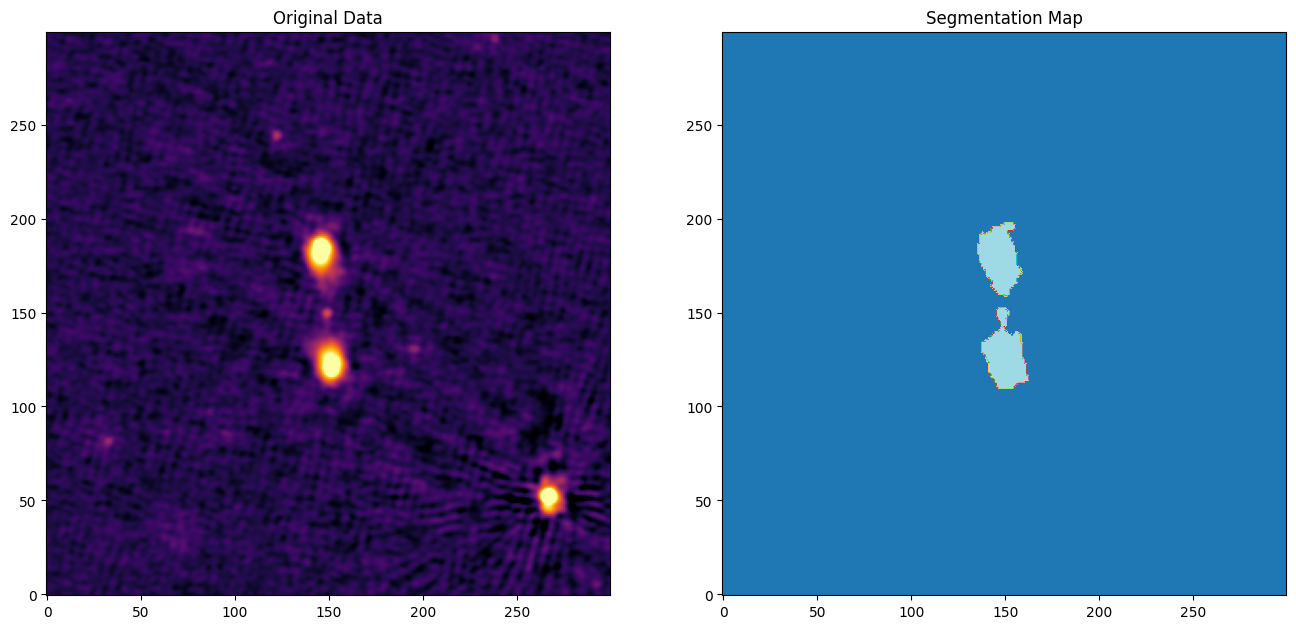

In [14]:
simple_segmentation_visualize(data, segmenter, seg_map=False)

# We can also create a segmantation map containing multiple objects in the cutout in a similar fashion using the SegmentationMap class:

In [17]:
from astro_datatools.lotss_annotations import SegmentationMap

seg_dict = {
    "main obj": segmenter,
    "obj 1": Segment([(265, 50)]),
}

segmentation_map_obj = SegmentationMap(seg_dict)

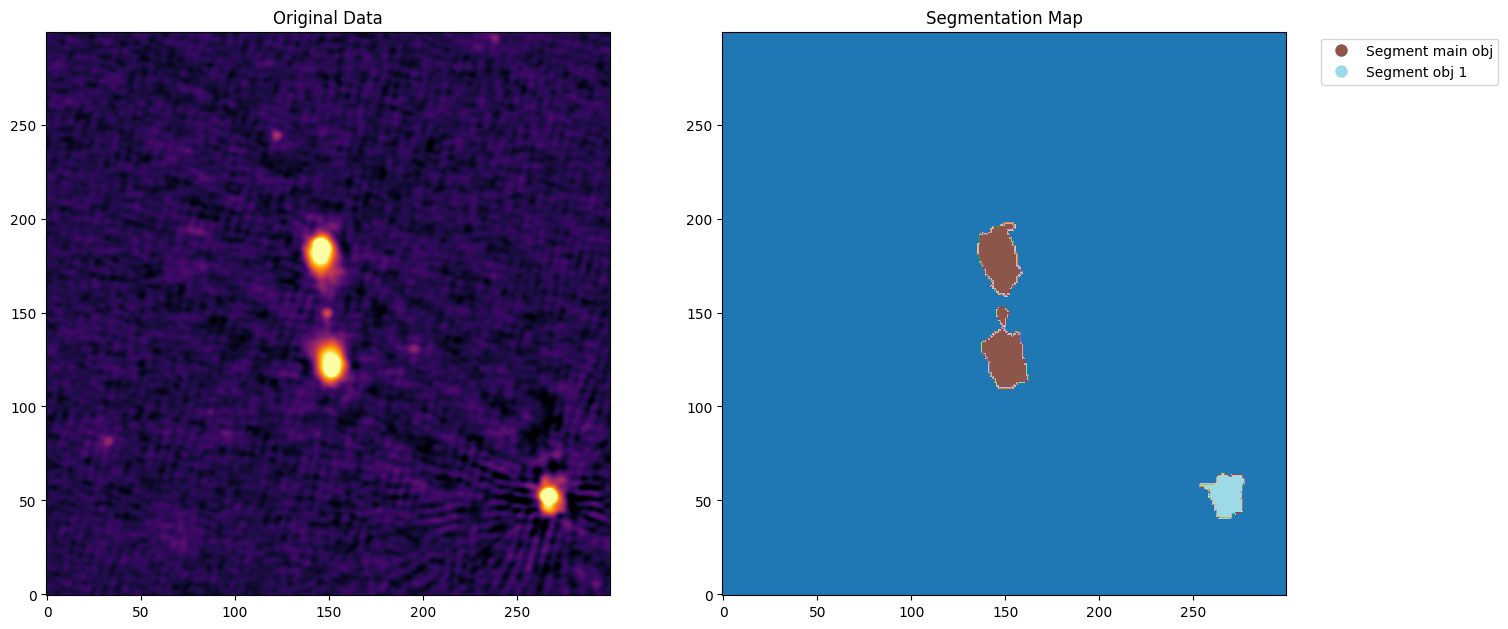

In [18]:
simple_segmentation_visualize(data, segmentation_map_obj, seg_map=True)

# We can also use the segmentation dictionary to create boundary boxes (or BBoxes) around the segmented objects:

In [19]:
from astro_datatools.lotss_annotations import BBox

bbox_dict = seg_dict

bbox = BBox(bbox_dict)

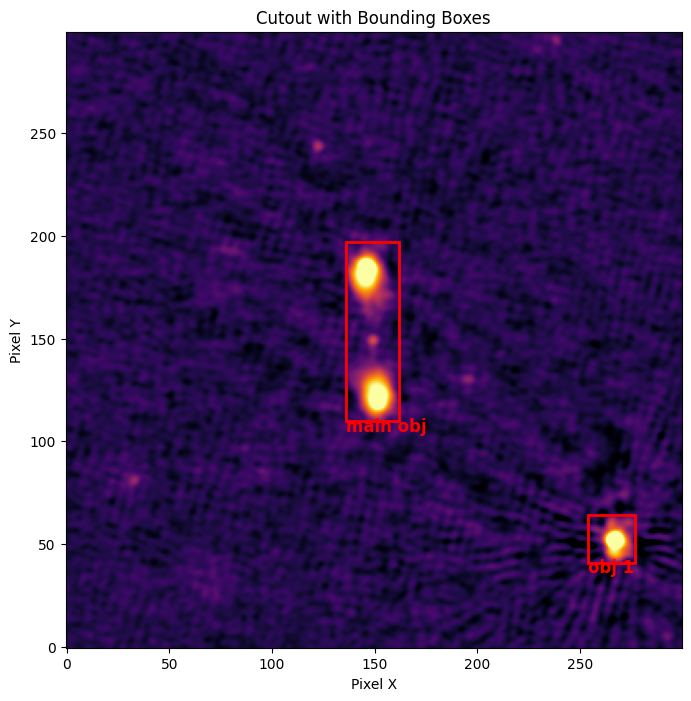

In [20]:
simple_bbox_visualize(data, bbox)

# Now lets create an example object using the LoTSSObject class from the cutout:

In [21]:
from astro_datatools.lotss_object import LoTSSObject
print(pixels)
grg = LoTSSObject(data, header, positions=pixels, nr_sigmas=5, rms=0.1*1e-3, metadata={"redshift":0.01}) # Example RA and DEC

grg_data = grg.get_object()

Cosmological Parameters used for calculating distances:
Omega_M: 0.30966
Omega_B: 0.04897
Omega_DM: 0.26069
Omega_Lambda: 0.6888463055445441
Omega_Rad: 0.0014936944554559178
Omega_Curv: 0.0
H0: 67.66 km/s/Mpc
c (speed of light): 299792.458 km/s
[(150, 110), (150, 175)]


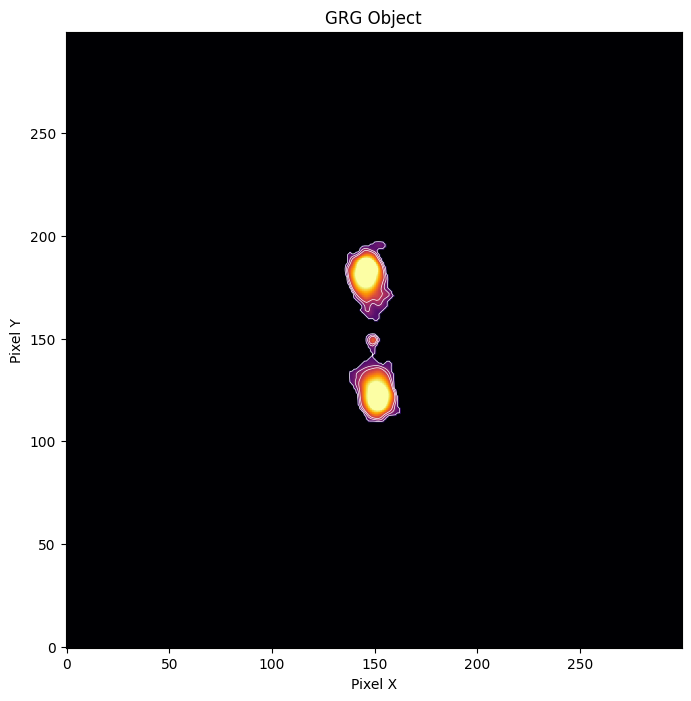

In [22]:
show_cutout(grg_data, title="GRG Object", contour_levels=[5, 10, 15])

# We can also reproject the object at a different redshift:

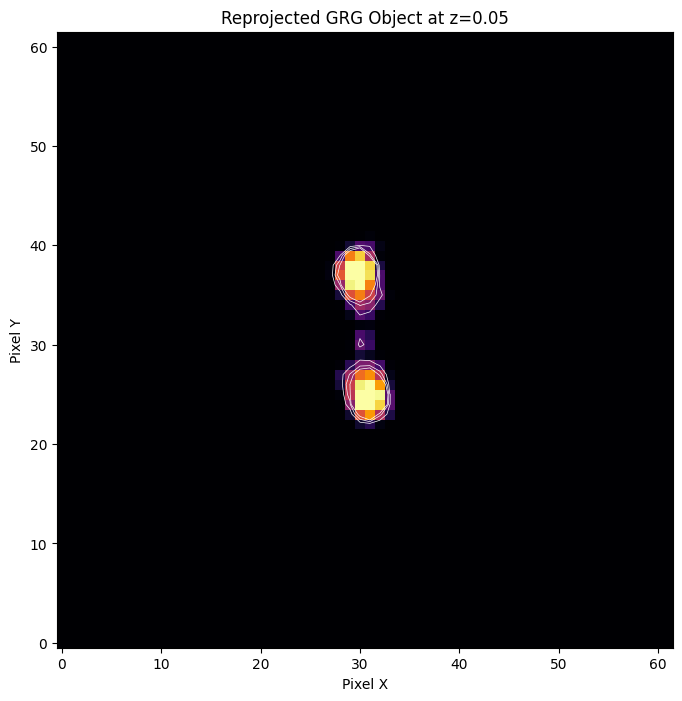

In [23]:
reprojected_grg_data = grg.redshift_reproject(desired_redshift=0.05)

show_cutout(reprojected_grg_data, title="Reprojected GRG Object at z=0.05", contour_levels=[5, 10, 15])

# We know that the intrinsic luminosity of the object should remain constant with redshift. Let's verify this by plotting luminosity vs redshift for our example GRG:

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from photutils.aperture import CircularAperture, aperture_photometry

from astro_datatools.lotss_object.cosmological_distances import luminosity_distance

def _S_to_Lnu(S, z, alpha=-0.7):
    """
    Convert observed flux density S (in Jy) at redshift z to intrinsic luminosity L_nu (in W/Hz).
    
    Parameters:
    - S: Observed flux density in Jy
    - z: Redshift
    - alpha: Spectral index (default is -0.7 for synchrotron emission)
    
    Returns:
    - L_nu: Intrinsic luminosity in W/Hz
    """
    D_L = luminosity_distance(z) * 3.086e22  # Convert Mpc to meters
    S_W_m2_Hz = S * 1e-26  # Convert Jy to W/m^2/Hz

    #K_CORRECTION = (1 + z)**(alpha - 1)

    L_nu = S_W_m2_Hz * 4 * np.pi * D_L**2 # * K_CORRECTION

    return L_nu # in W/Hz

def _calculate_luminosity(data, header, aperture, apperture_radius, rms, z):
    # Calculate the apperture sum (Flux = S_nu)
    phot_table = aperture_photometry(data, aperture, method='exact')  # sum of pixel VALUES (Jy/beam)
    flux = phot_table['aperture_sum'][0]

    # Calculate the aperture area in steradians
    pix_scale_deg = abs(header.get('CDELT1') or header.get('CD1_1'))  # degrees per pixel
    pix_scale_rad = np.deg2rad(pix_scale_deg)
    aper_area_sr = np.pi * (apperture_radius * pix_scale_rad)**2 # sr

    # solid angles
    # Get the BMAJ in deg
    bmaj_deg = header.get('BMAJ')   # degrees
    bmin_deg = header.get('BMIN')   # degrees

    # pixel scale (assume square pixels or use cdelt)
    pix_scale_deg = abs(header.get('CDELT1') or header.get('CD1_1'))  # degrees per pixel
    pix_scale_rad = np.deg2rad(pix_scale_deg)
    bmaj_rad = np.deg2rad(bmaj_deg)
    bmin_rad = np.deg2rad(bmin_deg)

    # solid angles
    omega_beam = (np.pi / (4.0 * np.log(2.0))) * bmaj_rad * bmin_rad  # sr

    # uncertainty in flux
    N_beams = aper_area_sr / omega_beam # number of beams in the aperture
    sigma_S = rms * np.sqrt(N_beams) # in Jy

    # Convert flux to luminosity
    L_nu = _S_to_Lnu(flux, z, alpha=-0.7) # in W/Hz

    # uncertainty in luminosity - must apply same K-correction as the main calculation
    L_nu_uncertainty = _S_to_Lnu(sigma_S, z, alpha=-0.7) # in W/Hz
    return L_nu, L_nu_uncertainty


def plot_luminosity_vs_redshift(lotss_object: LoTSSObject, 
                          z_max=1.0, num_points=50, aperture_radius=195, title="Luminosity vs Redshift"):
    """
    Plots the luminosity with error bars as a function of redshift.

    Parameters:
    -----------
    data_jyperpix : array
        Image data in Jy/pixel units
    empty_cutout_data_jyperpix : array
        Empty cutout data in Jy/pixel units for background
    header : astropy.io.fits.Header
        FITS header with WCS information
    rms : float
        RMS noise level for uncertainty calculation
    z_min : float
        Minimum redshift value (default: 0.0169)
    z_max : float
        Maximum redshift value (default: 1.0)
    num_points : int
        Number of redshift points to calculate (default: 50)
    aperture_radius : float
        Radius of circular aperture in pixels (default: 195)
    """
    z_min = lotss_object.redshift

    # Generate redshift values
    z_values = np.linspace(z_min, z_max, num_points)
    luminosities = []
    luminosity_uncertainties = []

    data_jyperpix = lotss_object.get_object()

    header = lotss_object.header
    rms = lotss_object.rms
    
    # Set up aperture (assuming it's centered)
    center_x = 150
    center_y = 150
    aperture_position = [(center_x, center_y)]
    aperture = CircularAperture(aperture_position, r=aperture_radius)
    
    print(f"Calculating power for {num_points} redshift values...")
    print(f"Redshift range: {z_min:.4f} to {z_max:.4f}")
    
    # Calculate power for each redshift
    for _, z2 in enumerate(z_values):
        # Reproject image for current redshift
        data_reprojected = lotss_object.redshift_reproject(z2, alpha=-0.7)

        # Create an empty array of the same shape as empty cutout
        empty_arr = np.zeros_like(data_jyperpix)

        # Add the reprojected data to the center of the empty cutout
        x_center = empty_arr.shape[1] // 2
        y_center = empty_arr.shape[0] // 2
        x_start = x_center - data_reprojected.shape[1] // 2
        y_start = y_center - data_reprojected.shape[0] // 2
        combined_data = empty_arr.copy()
        combined_data[y_start:y_start + data_reprojected.shape[0],
                      x_start:x_start + data_reprojected.shape[1]] += data_reprojected

        # Calculate luminosity and uncertainty within the aperture
        lum, lum_uncertainty = _calculate_luminosity(combined_data, header, aperture, aperture_radius, rms, z2)
        luminosities.append(lum)
        luminosity_uncertainties.append(lum_uncertainty)

    # Convert to numpy arrays
    luminosities = np.array(luminosities)
    luminosity_uncertainties = np.array(luminosity_uncertainties)

    # Create a figure with two subplots: log y-scale (top), linear y-scale (bottom)
    _, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    # Log y-scale plot (top)
    ax1.errorbar(z_values, luminosities, yerr=luminosity_uncertainties, 
                 fmt='o-', capsize=3, capthick=1, elinewidth=1, markersize=4,
                 color='blue', ecolor='lightblue', alpha=0.7)
    ax1.set_ylabel('W/Hz', fontsize=12)
    ax1.set_title(f'{title} (Log Scale)', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')

    # Linear y-scale plot (bottom)
    ax2.errorbar(z_values, luminosities, yerr=luminosity_uncertainties, 
                 fmt='o-', capsize=3, capthick=1, elinewidth=1, markersize=4,
                 color='blue', ecolor='lightblue', alpha=0.7)
    ax2.set_xlabel('z', fontsize=12)
    ax2.set_ylabel('W/Hz', fontsize=12)
    ax2.set_title(f'{title} (Linear Scale)', fontsize=14)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Calculating power for 50 redshift values...
Redshift range: 0.0100 to 1.0000


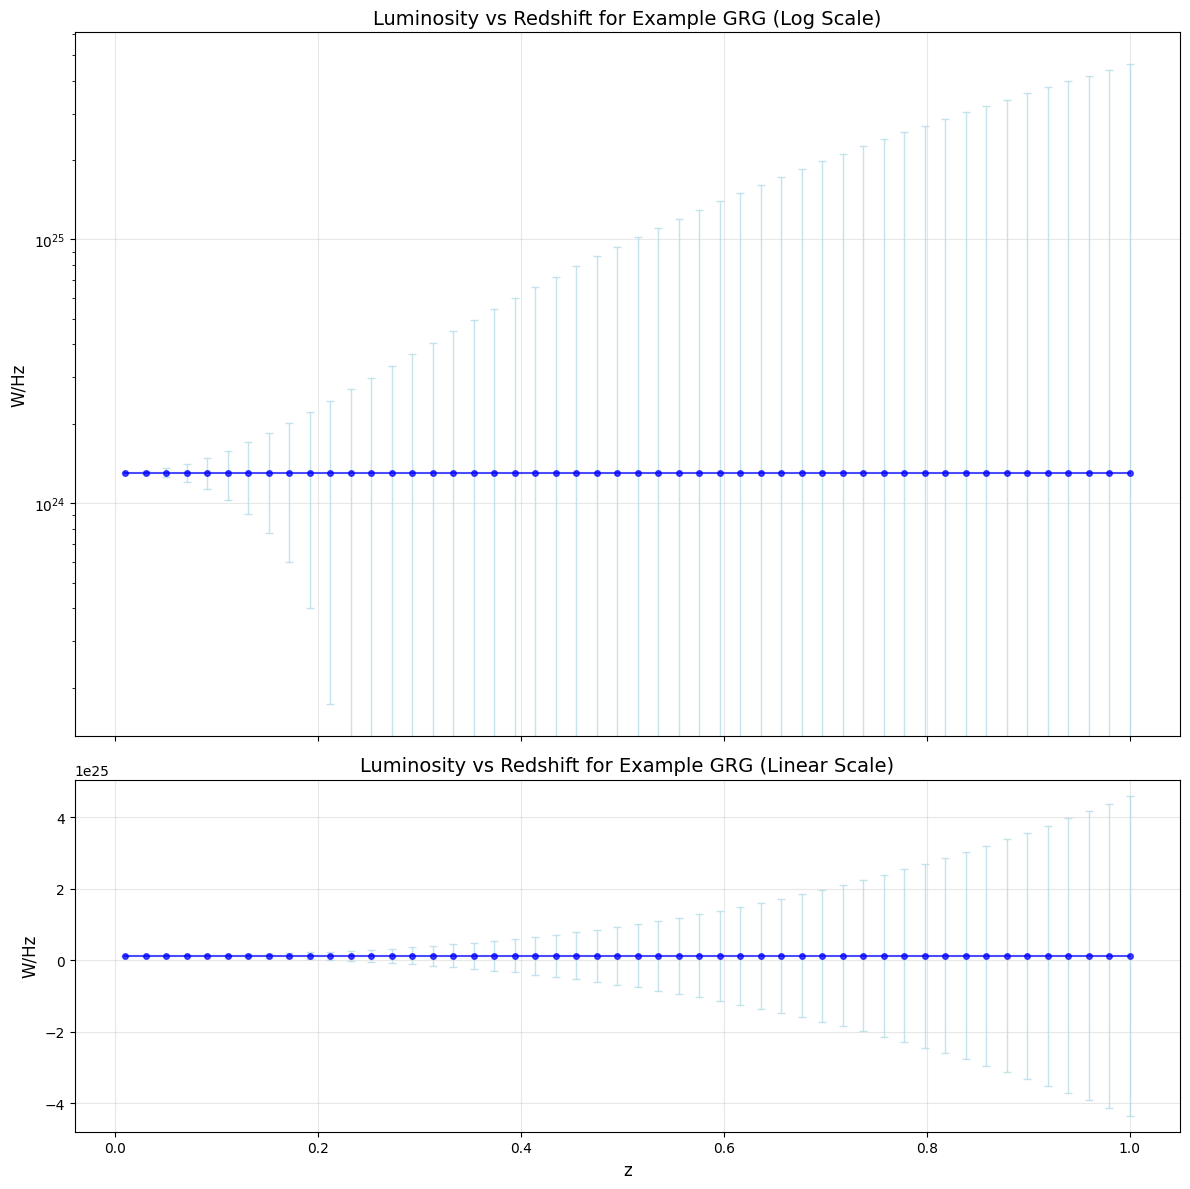

In [25]:
plot_luminosity_vs_redshift(grg, z_max=1.0, num_points=50, aperture_radius=195, title="Luminosity vs Redshift for Example GRG")